In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import simweights
import pickle
import os, sys
import re
import numpy as np
import matplotlib as mat
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import pandas as pd
import tables
import h5py
import math
from scipy.stats import mstats
import matplotlib as mpl
import matplotlib.font_manager as font_manager


In [3]:
livetime_yr = 11.687
livetime_s  = livetime_yr * 365.25 * 24 * 3600 # 11.687 year

In [4]:
def nan_to_zero(values):
    return np.array([0 if (isinstance(v, float) and math.isnan(v)) else v for v in values])

In [5]:
datasets_to_compare = ["21315","21316"]

hdf_file_path_thijs = "/data/user/tvaneede/GlobalFit/reco_processing/hdf/output/taureco_iceprod_v3/merged"
hdf_file_paths_thijs = {
    "21315" : f"{hdf_file_path_thijs}/HESE_MuonGun_MuonGun_21315.h5",
    "21316" : f"{hdf_file_path_thijs}/HESE_MuonGun_MuonGun_21316.h5",
    "21317" : f"{hdf_file_path_thijs}/HESE_MuonGun_MuonGun_21317.h5",
    "all"   : f"{hdf_file_path_thijs}/HESE_MuonGun_MuonGun.h5",
}

hdf_file_path_neha = "/data/ana/Diffuse/GlobalFit_Flavor/taupede/MuonGun/RecowithBfr/hdf_files/NoDeepCore/AllHESE/"
hdf_file_paths_neha = {
    "21315_Tracks" : f"{hdf_file_path_neha}/21315_Tracks.hdf5",
    "21315_Cascades" : f"{hdf_file_path_neha}/21315_Cascades.hdf5",
    "21315_DoubleCascades" : f"{hdf_file_path_neha}/21315_DoubleCascades.hdf5",

    "21316_Tracks" : f"{hdf_file_path_neha}/21316_Tracks.hdf5",
    "21316_Cascades" : f"{hdf_file_path_neha}/21316_Cascades.hdf5",
    "21316_DoubleCascades" : f"{hdf_file_path_neha}/21316_DoubleCascades.hdf5",
}

In [6]:
hdf_files_thijs = {}

for dataset_id, hdf_file_path in hdf_file_paths_thijs.items(): hdf_files_thijs[dataset_id] = tables.open_file( hdf_file_path ) 

hdf_files_neha = {}
for dataset_id, hdf_file_path in hdf_file_paths_neha.items(): hdf_files_neha[dataset_id] = tables.open_file( hdf_file_path ) 


In [7]:
# lets see how many events Neha found: 
dataset_id = "21317"
subfolders = [f"{i:07d}-{i+999:07d}" for i in range(0, 20000, 1000)]

dataset_id = "21316"
subfolders = [f"{i:07d}-{i+999:07d}" for i in range(0, 40000, 1000)]

dataset_id = "21315"
subfolders = [f"{i:07d}-{i+999:07d}" for i in range(0, 15000, 1000)]

total = 0
for subfolder in subfolders:
    total_subfolder = 0
    print(10*"-", dataset_id,subfolder)
    for channel in ["Tracks", "Cascades", "DoubleCascades"]:
        hdf_file_path = f"/data/ana/Diffuse/GlobalFit_Flavor/taupede/MuonGun/RecowithBfr/hdf_files/NoDeepCore/AllHESE/{dataset_id}_{channel}_{subfolder}.hdf5"
        hdf_file = tables.open_file(hdf_file_path)
        try:
            print(channel, hdf_file.get_node("/I3EventHeader")[:]["Event"])
            total_subfolder += len(hdf_file.get_node("/I3EventHeader")[:]["Event"])
        except: 
            # print(channel, [])
            continue
    print("total_subfolder", total_subfolder)
    total += total_subfolder
print("total",total)

---------- 21315 0000000-0000999
Tracks [231]
total_subfolder 1
---------- 21315 0001000-0001999
Tracks [264 176]
total_subfolder 2
---------- 21315 0002000-0002999
Tracks [266  54]
total_subfolder 2
---------- 21315 0003000-0003999
Tracks [274  72  52 384]
total_subfolder 4
---------- 21315 0004000-0004999
Tracks [65]
total_subfolder 1
---------- 21315 0005000-0005999
Tracks [11]
total_subfolder 1
---------- 21315 0006000-0006999
Tracks [ 95  67 190 390]
total_subfolder 4
---------- 21315 0007000-0007999
Tracks [393 447]
total_subfolder 2
---------- 21315 0008000-0008999
Tracks [144]
total_subfolder 1
---------- 21315 0009000-0009999
Tracks [301]
total_subfolder 1
---------- 21315 0010000-0010999
total_subfolder 0
---------- 21315 0011000-0011999
total_subfolder 0
---------- 21315 0012000-0012999
Tracks [180]
total_subfolder 1
---------- 21315 0013000-0013999
total_subfolder 0
---------- 21315 0014000-0014999
Tracks [382]
total_subfolder 1
total 21


Neha finds for AllHESE
21315: 21 events
21316: 25 events
21317: 0  events 

This now matches exactly what I have
python count_pframes.py "/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/muons/hese/filter/output/v4/21316/*"
python count_pframes.py "/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/muons/hese/filter/output/v4/21315/*"
what was wrong? probably many things. running hese filter with 500 frames, merging and duplicating the same hdf file multiple times

How many are there in my hdf5 file?

In [7]:
for dataset_id, hdf_file in hdf_files_thijs.items():    
    try:
        print(dataset_id,len(hdf_file.get_node("/I3EventHeader")[:]["Event"]))
        # print(hdf_file.get_node("/I3EventHeader")[:]["Event"])
    except:
        print(dataset_id,0)

21315 21
21316 25
21317 0
all 46


There I goddamn miss events again.. Only in the 21315 one. Have I reconstructed them?
No! In 
python count_pframes.py "/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/muons/hese/output/21315/EvtGen/*"
we only have 12. Same as for Taupede. Lets check the log file.

Boom. We need an old gcd. See /scratch/tvaneede/reco/run_taupede_muon/muongun/reco_dag_muongun_hese_v4/logs/21315.0001000-0001999.err
FATAL (millipede): Pulse on OM(67,49,0) that is not part of the detector configuration (MillipedeDOMCacheMap.cxx:342 in void MillipedeDOMCacheMap::UpdateData(const I3TimeWindow&, const I3RecoPulseSeriesMap&, const I3TimeWindowSeriesMap&, double, double, double, bool))

The muon datasets actually use:
"gcdfile_pass2":"/cvmfs/icecube.opensciencegrid.org/data/GCD/GeoCalibDetectorStatus_AVG_55697-57531_PASS2_SPE_withScaledNoise.i3.gz",


Now fixed in taureco_iceprod_v3!!


I have one event with a NaN weight

In [12]:
hdf_files_thijs["all"].get_node("/MuonWeightConv").cols.value[:]

array([2.50183782e-11, 4.81207407e-13, 5.59175071e-12, 1.26086559e-11,
       4.10297385e-12, 6.65727434e-12, 1.15428641e-11, 1.73185411e-11,
       1.03970469e-11, 1.14591104e-11, 9.94058041e-13,            nan,
       8.59713984e-11, 5.15106910e-11, 1.21294234e-10, 5.27780685e-11,
       2.58126365e-12, 5.26546453e-13, 1.65460437e-11, 6.03596643e-11,
       8.88594511e-12, 1.64333451e-10, 2.72137772e-10, 2.55872077e-09,
       1.43424942e-10, 1.11137178e-10, 1.02738684e-10, 1.96165464e-10,
       7.63587080e-10, 4.47117723e-09, 3.33986085e-09, 9.08558908e-10,
       1.03025704e-10, 4.12865368e-10, 1.81685529e-10, 1.03712742e-10,
       1.71394282e-09, 1.26861659e-10, 1.12441434e-10, 4.96388543e-09,
       3.32104673e-10, 2.18013467e-10, 1.25490037e-10, 1.53707313e-09,
       1.33607129e-10, 1.26901353e-09])

In [14]:
# does neha also have this?
for dataset_id, hdf_file in hdf_files_neha.items():
    try:
        print(dataset_id)
        print(hdf_file.get_node("/MuonWeightConv").cols.value[:])
    except: continue

21315_Tracks
[1.73184223e-11 6.03596643e-11 1.65293721e-11 1.24806638e-11
 4.10252678e-12 5.26546453e-13 5.27722537e-11 1.21294234e-10
 2.57891189e-12 1.14587147e-11 1.15427779e-11 5.15067111e-11
 6.87328935e-12 8.59707547e-11 9.94058041e-13 4.81207407e-13
 5.59175071e-12 8.87870565e-12 6.65727434e-12 2.50176973e-11
 1.03970469e-11]
21315_Cascades
21315_DoubleCascades
21316_Tracks
[1.96165464e-10            nan 1.26939904e-09 1.43424942e-10
 2.55955767e-09 1.03816559e-10 1.71397254e-09 2.72137772e-10
 4.96388543e-09 1.33607129e-10 1.03025704e-10 4.12865368e-10
 1.53711028e-09 2.18013467e-10 3.33986085e-09 3.32437110e-10
 1.12441434e-10 1.26861659e-10 4.47565288e-09 1.02738684e-10
 1.11137178e-10 1.81867396e-10]
21316_Cascades
[9.08569140e-10 1.25490037e-10 1.64333451e-10]
21316_DoubleCascades


Neha has the same. Let's remove this event. NNMFit doesnt take it into account.

Which energies and reconstructed lengths are these? Nehas 60 TeV cut made sure there are no muons in the cascade or double cascade channel. Can I reduce these cuts?

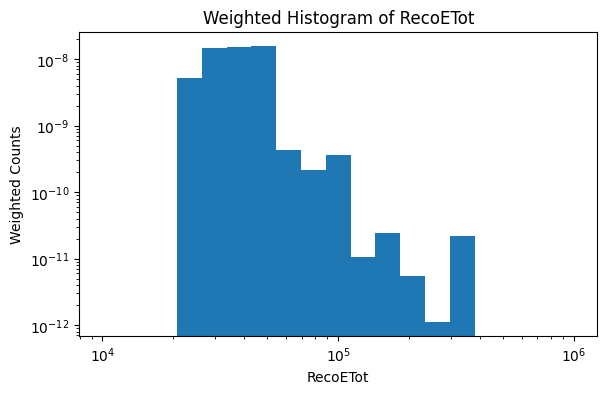

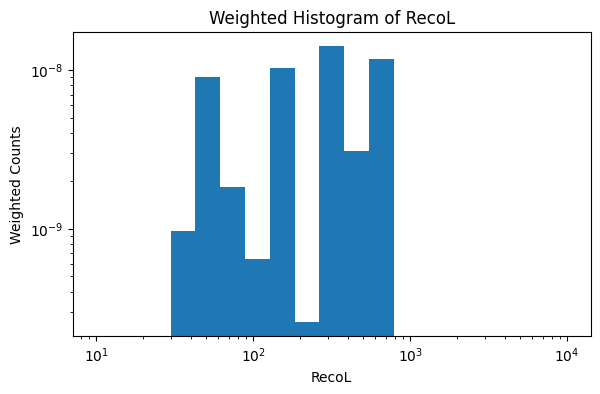

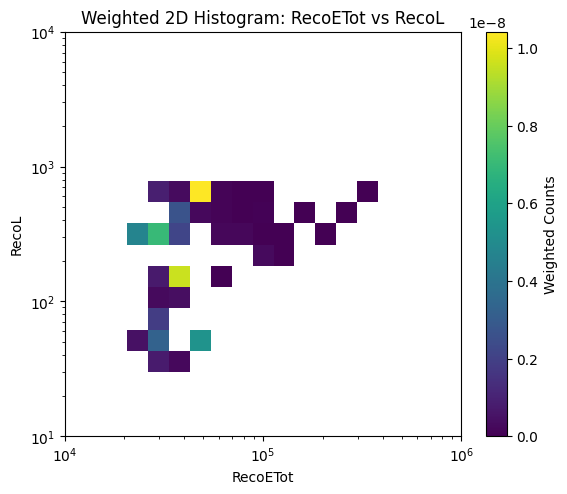

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize


# Load arrays from your HDF5 structure
RecoETot = hdf_files_thijs["all"].get_node("/RecoETot")[:]["value"]
RecoL = hdf_files_thijs["all"].get_node("/RecoL")[:]["value"]
weights = nan_to_zero( hdf_files_thijs["all"].get_node("/MuonWeightScaled")[:]["value"] )

bins_energy = np.geomspace(1e4,1e6,20)
bins_length = np.geomspace(1e1,1e4,20)

# --- 1) Weighted histogram of RecoETot ---
plt.figure(figsize=(6,4))
plt.hist(RecoETot, bins=bins_energy, weights=weights)
plt.xlabel("RecoETot")
plt.ylabel("Weighted Counts")
plt.title("Weighted Histogram of RecoETot")
plt.tight_layout()
plt.xscale("log")
plt.yscale("log")
plt.show()

# --- 2) Weighted histogram of RecoL ---
plt.figure(figsize=(6,4))
plt.hist(RecoL, bins=bins_length, weights=weights)
plt.xlabel("RecoL")
plt.ylabel("Weighted Counts")
plt.title("Weighted Histogram of RecoL")
plt.tight_layout()
plt.xscale("log")
plt.yscale("log")
plt.show()

# --- 3) Weighted 2D histogram: RecoETot vs RecoL ---
plt.figure(figsize=(6,5))
h = plt.hist2d(RecoETot, RecoL, bins=[bins_energy,bins_length], weights=weights)
# modify color map so "under" (zeros) are white
cmap = h[3].cmap
cmap = cmap.copy()
cmap.set_under("white")

# apply vmin>0 to force zero bins to use "under" color (white)
h[3].set_cmap(cmap)
h[3].set_norm(Normalize(vmin=1e-20))  # any tiny non-zero number
plt.xlabel("RecoETot")
plt.ylabel("RecoL")
plt.title("Weighted 2D Histogram: RecoETot vs RecoL")
plt.colorbar(label="Weighted Counts")
plt.tight_layout()
plt.xscale("log")
plt.yscale("log")
plt.show()
